# 3. Solving Linear Systems

A system of linear equations is one of the most fundamental objects in all of applied mathematics.  
This notebook builds geometric intuition for *what* a solution looks like, *when* it exists, and *how sensitive* it is to small changes.

**Key ideas:** geometric interpretation, Gaussian elimination, condition number.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

def setup_ax(ax, lim=6, title=""):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.axhline(0, color="k", lw=0.4)
    ax.axvline(0, color="k", lw=0.4)
    if title:
        ax.set_title(title, fontsize=13)

## 3.1 Geometric Interpretation in 2D

Each equation $a_1 x + a_2 y = b$ defines a **line** in the plane.  
Solving a system of two equations means finding the **intersection** of two lines.

Three cases:
1. **One unique solution** -- the lines cross at a single point.
2. **No solution** -- the lines are parallel (inconsistent system).
3. **Infinitely many solutions** -- the lines are identical (dependent system).

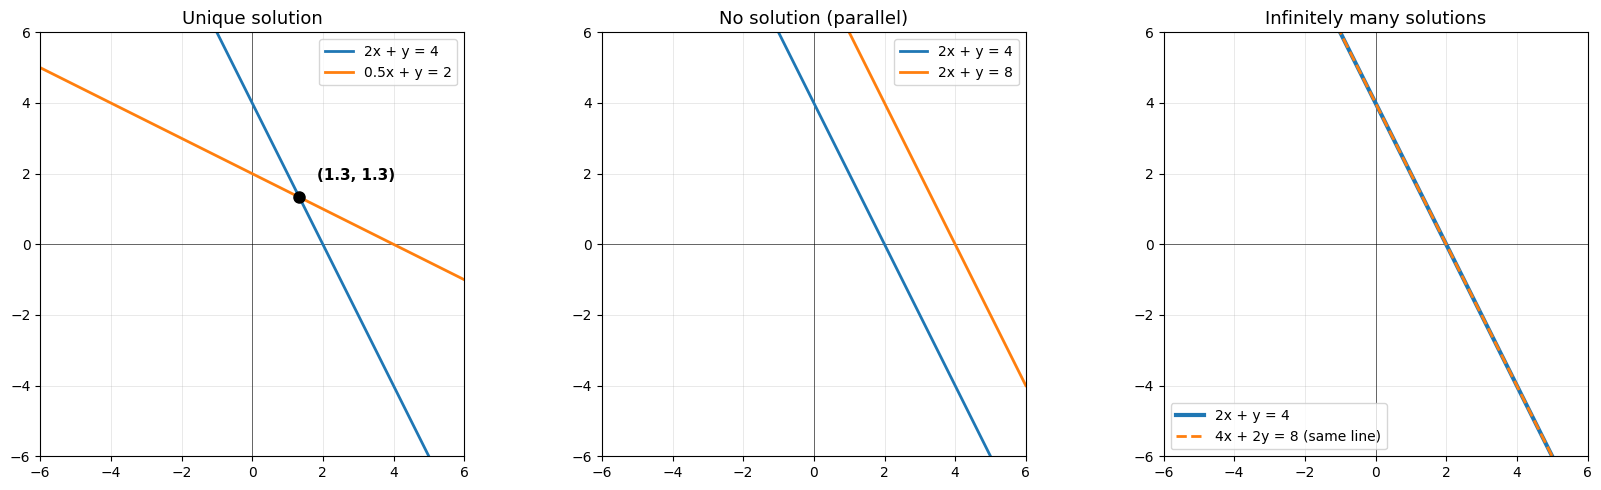

In [2]:
x = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Case 1: unique solution
ax = axes[0]
setup_ax(ax, title="Unique solution")
ax.plot(x, (4 - 2 * x) / 1, label="2x + y = 4", lw=2)
ax.plot(x, (2 - 0.5 * x) / 1, label="0.5x + y = 2", lw=2)
sol = np.linalg.solve([[2, 1], [0.5, 1]], [4, 2])
ax.plot(*sol, "ko", ms=8, zorder=5)
ax.annotate(
    f"({sol[0]:.1f}, {sol[1]:.1f})",
    xy=sol,
    xytext=(sol[0] + 0.5, sol[1] + 0.5),
    fontsize=11,
    fontweight="bold",
)
ax.legend(fontsize=10)

# Case 2: no solution (parallel)
ax = axes[1]
setup_ax(ax, title="No solution (parallel)")
ax.plot(x, (4 - 2 * x), label="2x + y = 4", lw=2)
ax.plot(x, (8 - 2 * x), label="2x + y = 8", lw=2)
ax.legend(fontsize=10)

# Case 3: infinitely many (same line)
ax = axes[2]
setup_ax(ax, title="Infinitely many solutions")
ax.plot(x, (4 - 2 * x), label="2x + y = 4", lw=3)
ax.plot(x, (8 - 4 * x) / 2, "--", label="4x + 2y = 8 (same line)", lw=2)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 3.2 Gaussian Elimination -- Step by Step

Gaussian elimination transforms the system into **upper triangular form** using three elementary row operations:
1. Swap two rows.
2. Multiply a row by a non-zero scalar.
3. Add a multiple of one row to another.

We walk through an example below, printing each step.

In [3]:
def gaussian_elimination_verbose(A, b):
    """
    Solve Ax = b via Gaussian elimination with partial pivoting, printing each step.

    Parameters
    ----------
    A : ndarray, shape (n, n)
    b : ndarray, shape (n,)

    Returns
    -------
    x : ndarray, shape (n,)
    """
    n = len(b)
    Ab = np.hstack([A.astype(float), b.astype(float).reshape(-1, 1)])
    print("Augmented matrix [A | b]:")
    print(np.round(Ab, 4), "\n")

    for col in range(n):
        pivot_row = col + np.argmax(np.abs(Ab[col:, col]))
        if pivot_row != col:
            Ab[[col, pivot_row]] = Ab[[pivot_row, col]]
            print(f"  Swap row {col} ↔ row {pivot_row}")

        for row in range(col + 1, n):
            factor = Ab[row, col] / Ab[col, col]
            Ab[row] -= factor * Ab[col]
            print(f"  R{row} ← R{row} - ({factor:.4f}) × R{col}")

        print(np.round(Ab, 4), "\n")

    # Back-substitution
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, -1] - Ab[i, i + 1 : n] @ x[i + 1 : n]) / Ab[i, i]

    print(f"Solution: x = {np.round(x, 6)}")
    return x

In [4]:
A = np.array([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]], dtype=float)
b = np.array([8, -11, -3], dtype=float)

x = gaussian_elimination_verbose(A, b)

print(f"\nVerification  A @ x = {A @ x}  (should be {b})")

Augmented matrix [A | b]:
[[  2.   1.  -1.   8.]
 [ -3.  -1.   2. -11.]
 [ -2.   1.   2.  -3.]] 

  Swap row 0 ↔ row 1
  R1 ← R1 - (-0.6667) × R0
  R2 ← R2 - (0.6667) × R0
[[ -3.      -1.       2.     -11.    ]
 [  0.       0.3333   0.3333   0.6667]
 [  0.       1.6667   0.6667   4.3333]] 

  Swap row 1 ↔ row 2
  R2 ← R2 - (0.2000) × R1
[[ -3.      -1.       2.     -11.    ]
 [  0.       1.6667   0.6667   4.3333]
 [  0.       0.       0.2     -0.2   ]] 

[[ -3.      -1.       2.     -11.    ]
 [  0.       1.6667   0.6667   4.3333]
 [  0.       0.       0.2     -0.2   ]] 

Solution: x = [ 2.  3. -1.]

Verification  A @ x = [  8. -11.  -3.]  (should be [  8. -11.  -3.])


## 3.3 Condition Number -- Sensitivity to Perturbations

The **condition number** $\kappa(A)$ measures how much the solution can change when the input data changes slightly.

$$\kappa(A) = \|A\| \, \|A^{-1}\|$$

- $\kappa \approx 1$: **well-conditioned** -- small input errors cause small output errors.
- $\kappa \gg 1$: **ill-conditioned** -- small input errors can cause huge output errors.

### Geometric picture

An ill-conditioned 2×2 system corresponds to two lines that are **nearly parallel**.  
A tiny nudge to either line shifts the intersection point by a large amount.

In [5]:
def plot_condition_comparison(
    A_good, b_good, A_bad, b_bad, noise_scale=0.05, n_trials=80
):
    """
    Compare a well-conditioned and ill-conditioned system under noise.

    Parameters
    ----------
    A_good, A_bad : ndarray (2,2)
    b_good, b_bad : ndarray (2,)
    noise_scale : float
    n_trials : int
    """
    rng = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, A, b, label in [
        (axes[0], A_good, b_good, "Well-conditioned"),
        (axes[1], A_bad, b_bad, "Ill-conditioned"),
    ]:
        kappa = np.linalg.cond(A)
        sol = np.linalg.solve(A, b)

        setup_ax(ax, lim=6, title=f"{label}\nκ(A) = {kappa:.1f}")

        xx = np.linspace(-6, 6, 400)
        for i in range(2):
            if A[i, 1] != 0:
                ax.plot(xx, (b[i] - A[i, 0] * xx) / A[i, 1], lw=2)

        ax.plot(*sol, "ko", ms=8, zorder=5, label="exact solution")

        perturbed = []
        for _ in range(n_trials):
            b_noisy = b + rng.normal(scale=noise_scale, size=2)
            try:
                s = np.linalg.solve(A, b_noisy)
                perturbed.append(s)
            except np.linalg.LinAlgError:
                pass

        perturbed = np.array(perturbed)
        ax.scatter(
            perturbed[:, 0],
            perturbed[:, 1],
            s=12,
            alpha=0.5,
            color="red",
            label="perturbed solutions",
        )
        ax.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

> **Try it!** Run the cell below. Does it succeed? If not, inspect `A_bad` closely — what is the relationship between its two rows?

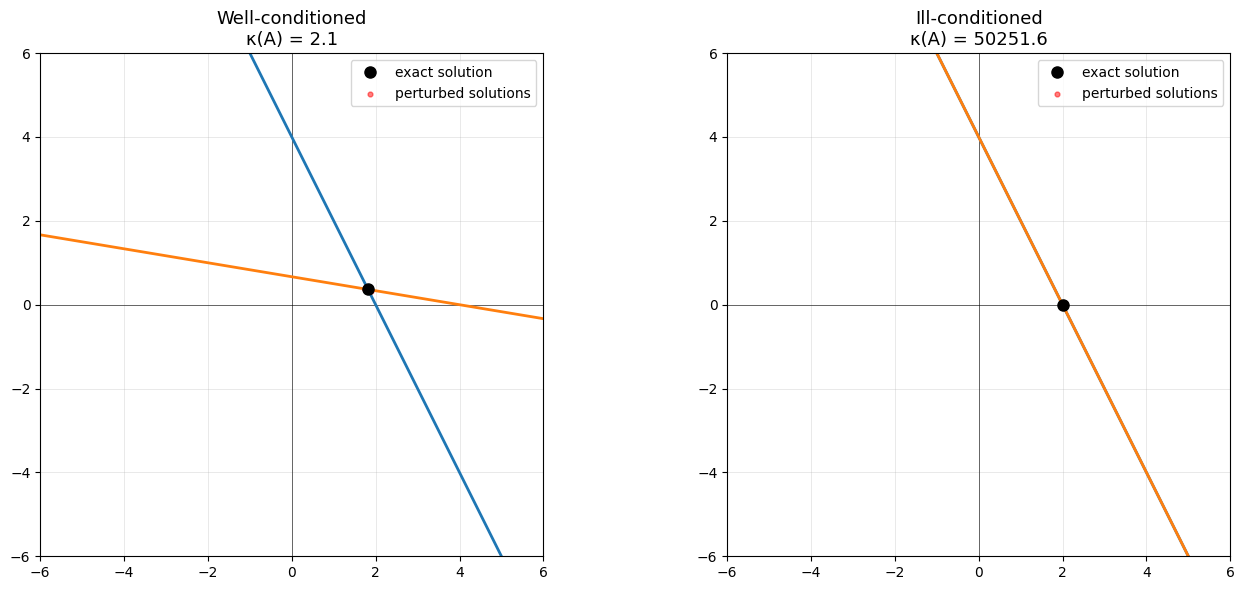

In [6]:
A_good = np.array([[2, 1], [0.5, 3]])
b_good = np.array([4, 2])

A_bad = np.array([[2, 1], [2.01, 1.0051]])
b_bad = np.array([4, 4.02])

plot_condition_comparison(A_good, b_good, A_bad, b_bad)

> **What happened?** The matrix `A_bad` is not merely ill-conditioned — it is **singular**.
> Notice that `[2.01, 1.005] = 1.005 × [2, 1]`, so the two rows are linearly dependent and `det(A_bad) = 0`.
> `np.linalg.solve` cannot invert a singular matrix and raises `LinAlgError`.
>
> **Exercise:** Modify `A_bad` above so that it is *ill-conditioned* (high κ) but **not** singular.
> For example, try changing `1.005` → `1.0051` and re-run.

### Interactive: Add noise and observe the effect

In [7]:
def interactive_noise(noise_scale):
    plot_condition_comparison(
        np.array([[2, 1], [0.5, 3]]),
        np.array([4, 2]),
        np.array([[2, 1], [2.01, 1.0051]]),
        np.array([4, 4.02]),
        noise_scale=noise_scale,
    )


widgets.interact(
    interactive_noise,
    noise_scale=widgets.FloatSlider(
        value=0.05, min=0.0, max=0.3, step=0.01, description="noise σ"
    ),
)

interactive(children=(FloatSlider(value=0.05, description='noise σ', max=0.3, step=0.01), Output()), _dom_clas…

<function __main__.interactive_noise(noise_scale)>

## 3.4 Extending to 3D

In 3D, each equation defines a **plane**.  Three planes generically intersect at a single point.  
Below we visualise a 3-equation system as three planes.

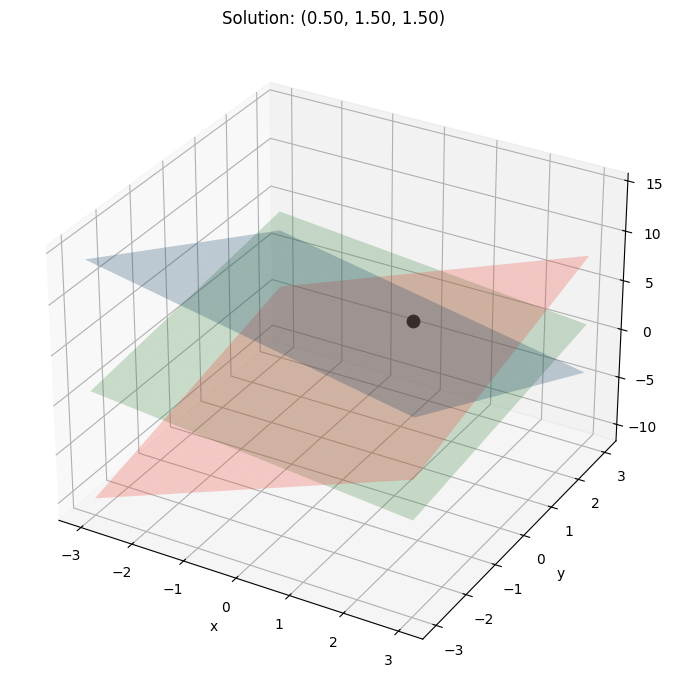

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

xx, yy = np.meshgrid(np.linspace(-3, 3, 20), np.linspace(-3, 3, 20))

# 3 planes: a1*x + a2*y + a3*z = b  =>  z = (b - a1*x - a2*y) / a3
planes = [
    (np.array([1, 2, 1]), 5, "Plane 1"),
    (np.array([2, 1, -1]), 1, "Plane 2"),
    (np.array([1, -1, 2]), 2, "Plane 3"),
]
colors = ["#2196F3", "#F44336", "#4CAF50"]

for (a, b, lbl), c in zip(planes, colors):
    zz = (b - a[0] * xx - a[1] * yy) / a[2]
    ax.plot_surface(xx, yy, zz, alpha=0.25, color=c, label=lbl)

A = np.array([p[0] for p in planes])
bvec = np.array([p[1] for p in planes])
sol = np.linalg.solve(A, bvec)
ax.scatter(*sol, color="k", s=80, zorder=5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Solution: ({sol[0]:.2f}, {sol[1]:.2f}, {sol[2]:.2f})")
plt.tight_layout()
plt.show()

---

## Exercises

### Exercise 1

Solve the following system by hand using Gaussian elimination, then verify with numpy:

$$\begin{cases} x + 2y = 5 \\ 3x - y = 1 \end{cases}$$

<details>
<summary><b>Solution</b></summary>

Subtract 3×(row 1) from row 2: $-7y = -14 \Rightarrow y = 2$, then $x = 5 - 4 = 1$.  
Solution: $(x, y) = (1, 2)$.

</details>

In [9]:
# Verification
A = np.array([[1, 2], [3, -1]], dtype=float)
b = np.array([5, 1], dtype=float)
print("Solution:", np.linalg.solve(A, b))
print("Condition number:", np.linalg.cond(A))

Solution: [1. 2.]
Condition number: 1.4560832005096072


### Exercise 2

Compute the condition number of the matrix $A = \begin{pmatrix} 1 & 1 \\ 1 & 1.001 \end{pmatrix}$.  
Add noise of scale 0.01 to $b = (2, 2.001)^T$ and solve 100 times. How much does the solution vary?

<details>
<summary><b>Solution</b></summary>

$\kappa(A) \approx 4002$.  Even tiny noise ($\sigma = 0.01$) causes the solution to scatter over a wide range, because the two equations describe nearly parallel lines.

</details>

In [ ]:
# Verification
A = np.array([[1, 1], [1, 1.001]])
b = np.array([2, 2.001])
print(f"κ(A) = {np.linalg.cond(A):.1f}")

rng = np.random.default_rng(0)
solutions = np.array(
    [np.linalg.solve(A, b + rng.normal(scale=0.01, size=2)) for _ in range(100)]
)
print(f"Mean solution: {solutions.mean(axis=0)}")
print(f"Std  solution: {solutions.std(axis=0)}")

κ(A) = 4002.0
Mean solution: [-0.72184854  2.7211406 ]
Std  solution: [12.57425454 12.5677777 ]


: 

### Exercise 3

Modify the interactive noise widget above: try increasing $\sigma$ from 0 to 0.3 and observe.  
At roughly what noise level does the well-conditioned system also start showing visible scatter?